In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Set style visualisasi biar cakep
sns.set_theme(style="whitegrid")

In [ ]:
df = pd.read_csv('synthetic_umkm_data.csv')
df.head()

,ID,Monthly_Revenue,Net_Profit_Margin (%),Burn_Rate_Ratio,Transaction_Count,Avg_Historical_Rating,Review_Text,Review_Volatility,Business_Tenure_Months,Repeat_Order_Rate (%),Digital_Adoption_Score,Peak_Hour_Latency,Location_Competitiveness,Sentiment_Score,Class
0,1,6680716,22.72,0.811,161,4.75,"Transaksi digital lancar, proses checkout tida...",0.313,105,19.40,4.24,Low,9,-0.25,Growth
1,2,5819101,4.46,0.968,104,4.21,"Harga dan kualitas seimbang, pengalaman biasa ...",0.632,95,14.87,1.27,Med,10,0.00,Growth
2,3,5236404,-10.12,1.047,102,3.51,"Pelayanan standar, masih bisa ditingkatkan.",0.470,17,21.00,3.37,Med,8,0.00,Struggling
3,4,8043552,0.04,0.969,99,4.33,"Transaksi digital lancar, proses checkout tida...",0.206,109,30.62,5.41,Low,13,-0.25,Growth
4,5,6071256,4.22,0.954,115,4.34,Selalu repeat order karena kualitasnya terjaga...,0.232,74,20.87,2.67,Low,7,0.25,Growth


/tmp/ipykernel_251/4090973069.py:33: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='Class', ax=axes[2], palette='viridis', order=df['Class'].value_counts().index)


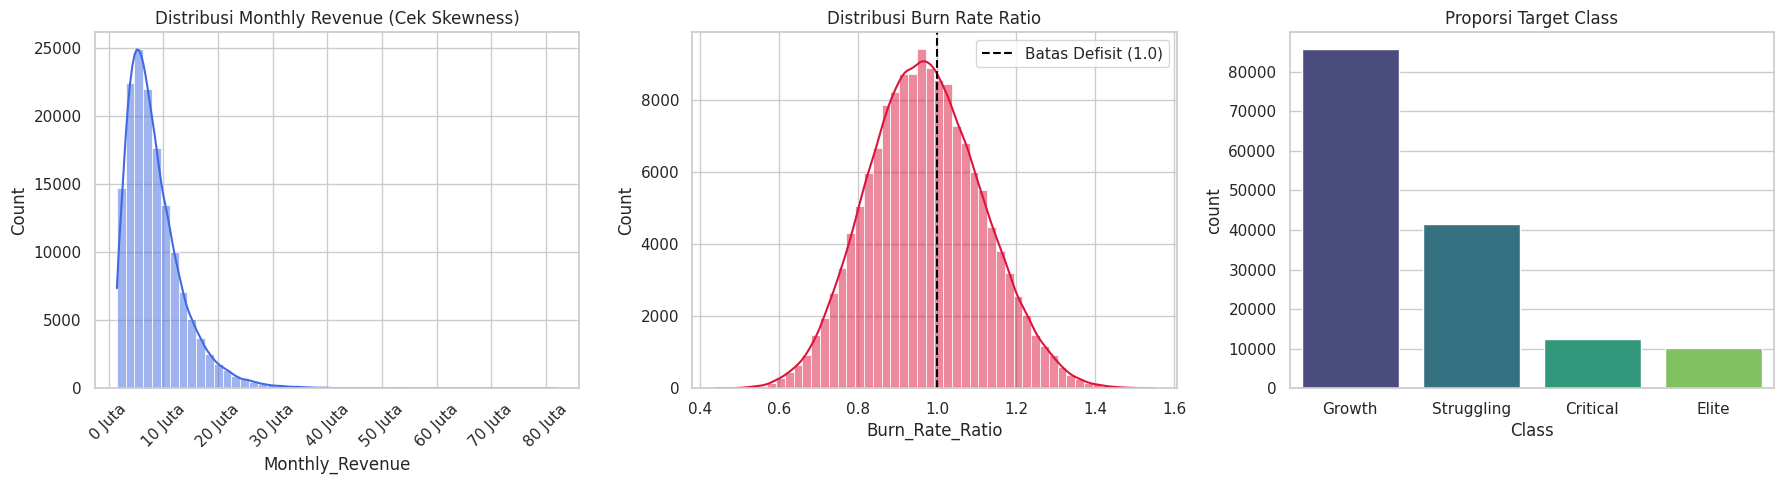

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.ticker as ticker

# Load dataset (sesuaikan nama filenya)
df = pd.read_csv('synthetic_umkm_data.csv')

# Set style visualisasi
sns.set_theme(style="whitegrid")

# Bikin fungsi buat ngubah format angka ke "Juta"
def format_rupiah(x, pos):
    return f"{int(x/1e6)} Juta"

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# 1. Distribusi Omzet (Sumbu X udah diformat)
sns.histplot(df['Monthly_Revenue'], bins=50, kde=True, ax=axes[0], color='royalblue')
axes[0].set_title('Distribusi Monthly Revenue (Cek Skewness)')
# Terapin formatnya ke sumbu X
axes[0].xaxis.set_major_formatter(ticker.FuncFormatter(format_rupiah))
# Putar teksnya dikit biar gak nabrak kalau angkanya panjang
axes[0].tick_params(axis='x', rotation=45)

# 2. Distribusi Burn Rate
sns.histplot(df['Burn_Rate_Ratio'], bins=50, kde=True, ax=axes[1], color='crimson')
axes[1].axvline(1.0, color='black', linestyle='--', label='Batas Defisit (1.0)')
axes[1].set_title('Distribusi Burn Rate Ratio')
axes[1].legend()

# 3. Class Imbalance Check
sns.countplot(data=df, x='Class', ax=axes[2], palette='viridis', order=df['Class'].value_counts().index)
axes[2].set_title('Proporsi Target Class')

plt.tight_layout()
plt.show()

Untuk menyimpan visualisasi yang sudah dibuat, Anda bisa menambahkan `plt.savefig()` setelah `plt.show()` di setiap blok kode visualisasi. Misalnya, untuk menyimpan heatmap korelasi sebagai file PNG, Anda bisa melakukannya seperti ini:

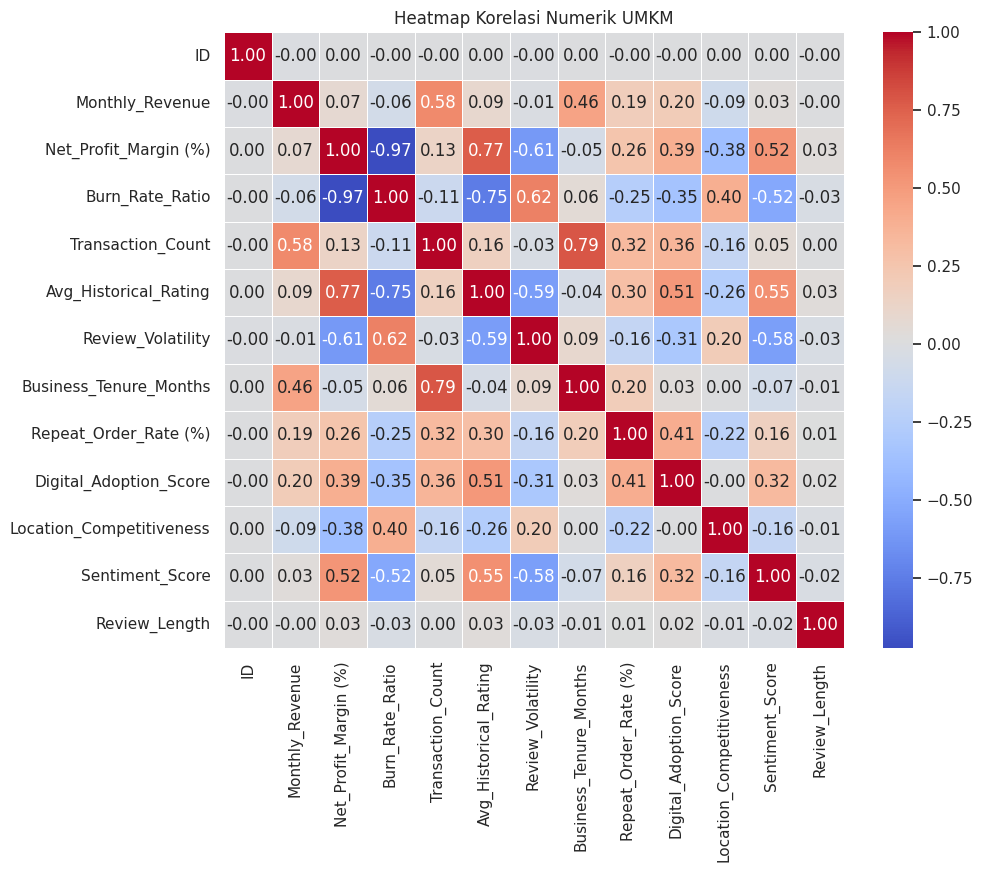

/tmp/ipykernel_251/119251943.py:16: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='Peak_Hour_Latency', y='Transaction_Count', order=['Low', 'Medium', 'High'], palette='Set2')


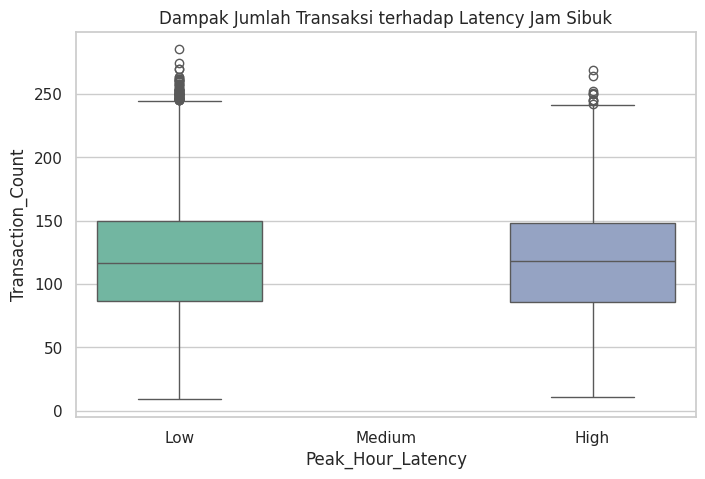

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Pastikan df dan numeric_cols sudah didefinisikan dari sel sebelumnya
# Heatmap Korelasi
plt.figure(figsize=(10, 8))
numeric_cols = df.select_dtypes(include=['float64', 'int64']).columns
corr_matrix = df[numeric_cols].corr()
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)
plt.title('Heatmap Korelasi Numerik UMKM')
plt.savefig('heatmap_korelasi_umkm.png') # Simpan plot sebagai file PNG
plt.show()

# Transaction Count vs Latency
plt.figure(figsize=(8, 5))
sns.boxplot(data=df, x='Peak_Hour_Latency', y='Transaction_Count', order=['Low', 'Medium', 'High'], palette='Set2')
plt.title('Dampak Jumlah Transaksi terhadap Latency Jam Sibuk')
plt.savefig('boxplot_transaksi_latency.png') # Simpan plot sebagai file PNG
plt.show()

Setelah kode di atas dieksekusi, Anda akan menemukan file `heatmap_korelasi_umkm.png` dan `boxplot_transaksi_latency.png` di direktori Colab Anda. Anda bisa mengunduhnya dari panel file di sebelah kiri.

/tmp/ipykernel_251/2317284744.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='Class', y='Burn_Rate_Ratio', ax=axes[0], palette='pastel')


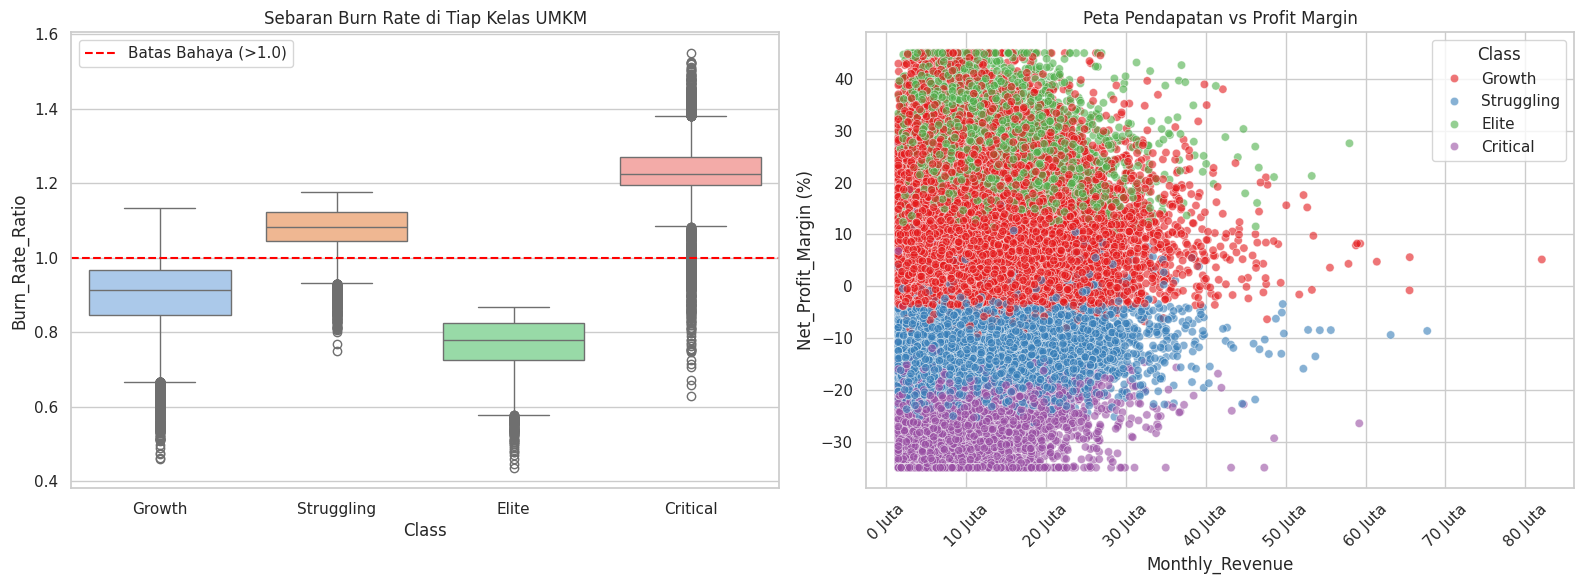

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Boxplot Burn Rate per Class
sns.boxplot(data=df, x='Class', y='Burn_Rate_Ratio', ax=axes[0], palette='pastel')
axes[0].axhline(1.0, color='red', linestyle='--', label='Batas Bahaya (>1.0)')
axes[0].set_title('Sebaran Burn Rate di Tiap Kelas UMKM')
axes[0].legend()

# Scatter Plot Revenue vs Profit (Diwarnain pake Class)
def format_rupiah(x, pos):
  return f"{int(x/1e6)} Juta"
sns.scatterplot(data=df, x='Monthly_Revenue', y='Net_Profit_Margin (%)', hue='Class', palette='Set1', alpha=0.6, ax=axes[1])
axes[1].xaxis.set_major_formatter(ticker.FuncFormatter(format_rupiah))
# Putar teksnya dikit biar gak nabrak kalau angkanya panjang
axes[1].tick_params(axis='x', rotation=45)
axes[1].set_title('Peta Pendapatan vs Profit Margin')

plt.tight_layout()
plt.show()

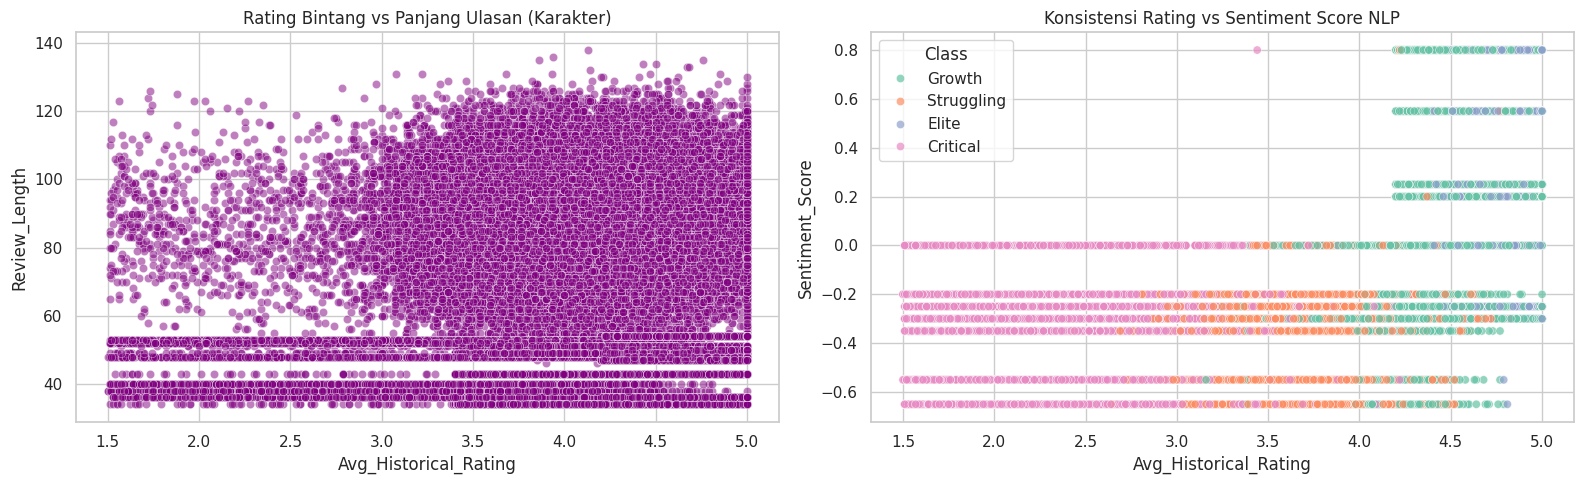

In [ ]:
# Bikin kolom baru sementara buat ngitung panjang teks review
df['Review_Length'] = df['Review_Text'].astype(str).apply(len)

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Panjang Teks vs Rating
sns.scatterplot(data=df, x='Avg_Historical_Rating', y='Review_Length', alpha=0.5, color='purple', ax=axes[0])
axes[0].set_title('Rating Bintang vs Panjang Ulasan (Karakter)')

# Sentiment Score vs Rating
sns.scatterplot(data=df, x='Avg_Historical_Rating', y='Sentiment_Score', hue='Class', palette='Set2', alpha=0.7, ax=axes[1])
axes[1].set_title('Konsistensi Rating vs Sentiment Score NLP')

plt.tight_layout()
plt.show()

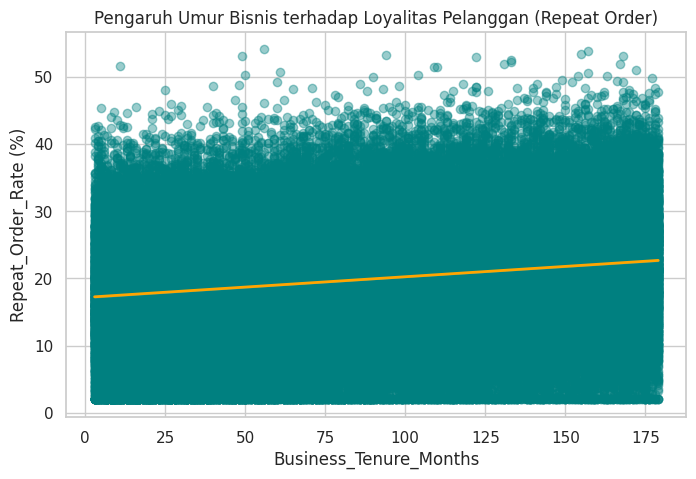

In [ ]:
plt.figure(figsize=(8, 5))
sns.regplot(data=df, x='Business_Tenure_Months', y='Repeat_Order_Rate (%)',
            scatter_kws={'alpha':0.4, 'color':'teal'},
            line_kws={'color':'orange', 'linewidth':2})
plt.title('Pengaruh Umur Bisnis terhadap Loyalitas Pelanggan (Repeat Order)')
plt.show()